In [ ]:
# MCA专门处理分类数据（降维/可视化）

# 假设你调研了消费者的三个维度：
# 性别（男/女）、职业（学生/白领/退休）、购买偏好（线上/线下）

# PCA/KMO：无法处理这些数据

# 对于列坐标图（特征与特征之间的关联性）
# 点与点的距离： 近=强关联性
# 点与原点（中心）的距离：近=特征大众化，没有区分度；远离原点的点，说明该特征非常典型，是区分不同人群的关键。
# 维度（坐标轴）的含义：需观察落在坐标轴两端的点分别是什么

# 对于行坐标图（样本与样本之间的关联性）
# 点与点的距离：近=相似的消费者

          0         1
0  1.396044 -0.317821
1  1.396044 -0.317821
2  1.396044 -0.317821
3  1.396044 -0.317821
4  1.396044 -0.317821
          0         1          Type Label
0  1.396044 -0.317821  Row (Sample)      
1  1.396044 -0.317821  Row (Sample)      
2  1.396044 -0.317821  Row (Sample)      
3  1.396044 -0.317821  Row (Sample)      
4  1.396044 -0.317821  Row (Sample)      


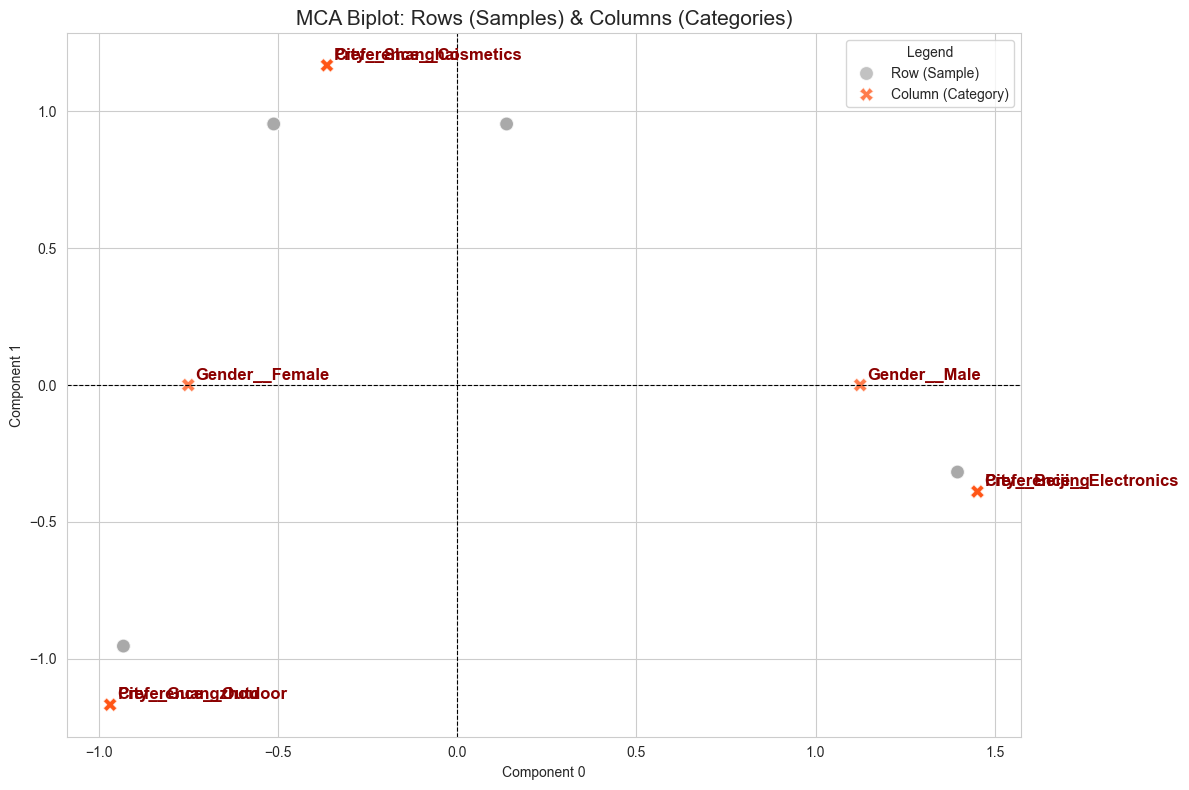

In [ ]:
import pandas as pd
import prince
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 构造演示数据
data = {
    'Gender': ['Male']*40 + ['Female']*60,
    'City': ['Beijing']*30 + ['Shanghai']*40 + ['Guangzhou']*30,
    'Preference': ['Electronics']*30 + ['Cosmetics']*40 + ['Outdoor']*30
}
df = pd.DataFrame(data)

# 2. 初始化 MCA 模型
mca = prince.MCA(
    n_components=2, #保留多少个“主成分”或“维度”
    n_iter=3, #奇异值分解（SVD）算法的迭代次数
    copy=True, #设为 True 可以防止模型直接修改原始的 df
    check_input=True,
    engine='sklearn',
    random_state=42
)

# 3. 拟合模型
mca = mca.fit(df)

# 4. 获取坐标数据
# 获取行坐标（样本/人）
row_coords = mca.row_coordinates(df)
print(row_coords.head())
row_coords['Type'] = 'Row (Sample)'
row_coords['Label'] = ''  # 样本点通常不加文字标签，否则图太乱
print(row_coords.head())

# 获取列坐标（特征/标签）
col_coords = mca.column_coordinates(df)
col_coords['Type'] = 'Column (Category)'
col_coords['Label'] = col_coords.index  # 列坐标需要显示标签

# 5. 合并数据以便 Seaborn 绘图
plot_df = pd.concat([row_coords, col_coords])
plot_df.columns = ['Dim 0', 'Dim 1', 'Type', 'Label'] #重命名

# 6. 使用 Seaborn 绘图
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 绘制散点图
# hue: 根据类型区分颜色
# style: 根据类型区分形状
# s: 点的大小
scatter = sns.scatterplot(
    data=plot_df, 
    x='Dim 0', 
    y='Dim 1', 
    hue='Type', 
    style='Type', 
    palette=['#A9A9A9', '#FF4500'], # 行用灰色，列用橙红色
    alpha=0.7,
    s=100
)

# 7. 为“列坐标”添加文字标签
# 我们只遍历列坐标的部分
for i in range(len(plot_df)): # 遍历df的每一行
    if plot_df.iloc[i]['Type'] == 'Column (Category)':
        plt.text( #text添加文本
            plot_df.iloc[i]['Dim 0'] + 0.02, # 稍微偏移一点防止挡住点
            plot_df.iloc[i]['Dim 1'] + 0.02, 
            plot_df.iloc[i]['Label'], 
            fontsize=12, 
            weight='bold',
            color='#8B0000'
        )

# 8. 装饰图表
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

# 获取解释方差百分比（如果需要的话）
# var_explained = mca.eigenvalues_summary['% of variance']
plt.title('MCA Biplot: Rows (Samples) & Columns (Categories)', fontsize=15)
plt.xlabel('Component 0')
plt.ylabel('Component 1')

plt.legend(title='Legend')
plt.tight_layout()
plt.show()

In [ ]:
# 方法	适用数据类型	             核心数学基础
# PCA	全是数值型 (Continuous)	    相关系数 / 协方差
# MCA	全是类别型 (Categorical)	卡方检验 / 对应分析
# FAMD	混合型 (Mixed)	            标准化 + 指示矩阵加权

ValueError: Unknown format code 'f' for object of type 'str'

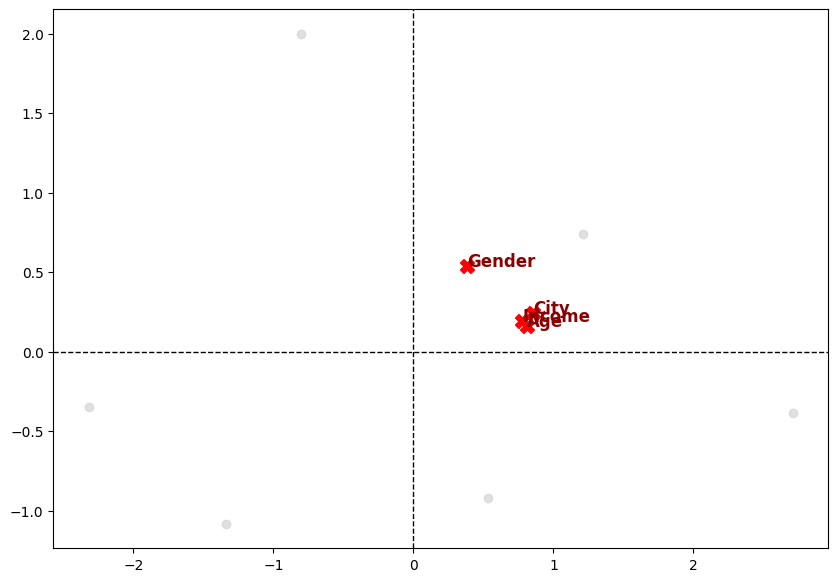

In [12]:
import pandas as pd
import prince

# 1. 构造混合数据
df = pd.DataFrame({
    'Age': [25, 32, 45, 50, 23, 38],
    'Income': [5000, 8000, 12000, 15000, 4500, 9000],
    'Gender': ['F', 'M', 'M', 'F', 'M', 'F'],
    'City': ['Beijing', 'Shanghai', 'Beijing', 'Guangzhou', 'Shanghai', 'Guangzhou']
})
df['Age'] = df['Age'].astype('float64')
df['Income'] = df['Income'].astype('float64')

# 2. 初始化 FAMD
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# 3. 拟合
famd = famd.fit(df)

# 3. 提取坐标
# 提取样本（行）坐标
row_coords = famd.row_coordinates(df)
# 提取变量（列）坐标
col_coords = famd.column_coordinates_

# 4. 手动绘图
plt.figure(figsize=(10, 7))

# 绘制样本点 (Rows) - 灰色小点
plt.scatter(row_coords[0], row_coords[1], c='lightgray', alpha=0.7, label='Samples')

# 绘制变量点 (Columns) - 红色大点
# 注意：FAMD 的 column_coordinates_ 包含了数值变量和类别选项
plt.scatter(col_coords[0], col_coords[1], c='red', s=100, marker='X', label='Variables/Levels')

# 给变量点加文字标签
for i, txt in enumerate(col_coords.index):
    plt.annotate(txt, (col_coords.iloc[i, 0], col_coords.iloc[i, 1]), 
                 fontsize=12, color='darkred', weight='bold')

# 画坐标轴中心线
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.axvline(x=0, color='k', linestyle='--', linewidth=1)

# 设置标签和标题
plt.xlabel(f"Component 0 ({famd.eigenvalues_summary['% of variance'][0]:.2f}%)")
plt.ylabel(f"Component 1 ({famd.eigenvalues_summary['% of variance'][1]:.2f}%)")
plt.title("FAMD Visualization (New API)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()